In [477]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [478]:

file_path = 'Retail_Apparel_Data_v1 (2).csv' 
df = pd.read_csv(file_path, dayfirst=True)

df.head()

,Invoice Number,Date Time,Customer ID,Product ID,Quantity,Price per Unit,Return Status,Sales Channel,Total Sales,Customer Age Group,Region,Product Category
0,10000,01/01/2021 10:20,74,3,2,24.00,Not Returned,In-Store,48.00,26-35,West,Footwear
1,10001,08/01/2021 03:10,92,10,6,40.24,Not Returned,In-Store,241.44,18-25,South,Footwear
2,1000,05/01/2021 20:24,86,20,5,25.96,Not Returned,Online,129.80,18-25,East,Clothing
3,10002,11/01/2021 03:43,57,11,6,85.86,Not Returned,Online,515.16,46-55,North,Clothing
4,10003,02/01/2021 07:26,73,25,5,72.88,Not Returned,In-Store,364.40,56+,West,Clothing


# Preprocessing

In [479]:
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d/%m/%Y %H:%M')

df['date'] = df['Date Time'].dt.date
df['date'] = pd.to_datetime(df['date'])


In [480]:
df.head()

,Invoice Number,Date Time,Customer ID,Product ID,Quantity,Price per Unit,Return Status,Sales Channel,Total Sales,Customer Age Group,Region,Product Category,date
0,10000,2021-01-01 10:20:00,74,3,2,24.00,Not Returned,In-Store,48.00,26-35,West,Footwear,2021-01-01
1,10001,2021-01-08 03:10:00,92,10,6,40.24,Not Returned,In-Store,241.44,18-25,South,Footwear,2021-01-08
2,1000,2021-01-05 20:24:00,86,20,5,25.96,Not Returned,Online,129.80,18-25,East,Clothing,2021-01-05
3,10002,2021-01-11 03:43:00,57,11,6,85.86,Not Returned,Online,515.16,46-55,North,Clothing,2021-01-11
4,10003,2021-01-02 07:26:00,73,25,5,72.88,Not Returned,In-Store,364.40,56+,West,Clothing,2021-01-02


In [481]:
filtered_df = df[df['date'] > pd.to_datetime('2021-01-31')]

In [482]:
filtered_df.head()

,Invoice Number,Date Time,Customer ID,Product ID,Quantity,Price per Unit,Return Status,Sales Channel,Total Sales,Customer Age Group,Region,Product Category,date
9764,19989,2031-01-26 01:03:00,16,24,3,63.78,Not Returned,Online,191.34,26-35,West,Accessories,2031-01-26


In [483]:
df = df[df['date'] != "2031-01-26"]


In [484]:
filtered_df = df[df['date'] > pd.to_datetime('2021-01-31')]


In [485]:
filtered_df.head()

,Invoice Number,Date Time,Customer ID,Product ID,Quantity,Price per Unit,Return Status,Sales Channel,Total Sales,Customer Age Group,Region,Product Category,date


In [486]:
print("Initial shape:", df.shape)
print(df.info())
print(df.head())

Initial shape: (16897, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 16897 entries, 0 to 16897
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Invoice Number      16897 non-null  int64         
 1   Date Time           16897 non-null  datetime64[ns]
 2   Customer ID         16897 non-null  int64         
 3   Product ID          16897 non-null  int64         
 4   Quantity            16897 non-null  int64         
 5   Price per Unit      16897 non-null  float64       
 6   Return Status       16897 non-null  object        
 7   Sales Channel       16897 non-null  object        
 8   Total Sales         16897 non-null  float64       
 9   Customer Age Group  16551 non-null  object        
 10  Region              16897 non-null  object        
 11  Product Category    16897 non-null  object        
 12  date                16897 non-null  datetime64[ns]
dtypes: datetime64[ns](2), fl

## handling misspelled feature names

In [487]:
print("Product Category:", df['Product Category'].unique())
print("Sales Channel:", df['Sales Channel'].unique())
print("Region:", df['Region'].unique())
print("Return Status:", df['Return Status'].unique())

Product Category: ['Footwear' 'Clothing' 'Accessories' 'Foot wear' 'Acessories']
Sales Channel: ['In-Store' 'Online' 'On line' 'In Store']
Region: ['West' 'South' 'East' 'North']
Return Status: ['Not Returned' 'Returned']


In [488]:
df['Product Category'] = df['Product Category'].replace({
    'Foot wear': 'Footwear',
    'Acessories': 'Accessories'
})

In [489]:
df['Sales Channel'] = df['Sales Channel'].replace({
    'In Store': 'In-Store',
    'On line': 'Online'
})

# Handling Missing Values

In [490]:
missing_summary = df.isnull().sum()
print("Missing values summary:\n", missing_summary)

Missing values summary:
 Invoice Number          0
Date Time               0
Customer ID             0
Product ID              0
Quantity                0
Price per Unit          0
Return Status           0
Sales Channel           0
Total Sales             0
Customer Age Group    346
Region                  0
Product Category        0
date                    0
dtype: int64


### Finding count for age groups

In [491]:
age_group_transaction_counts = df.groupby('Customer Age Group')['Invoice Number'].count().sort_values(ascending=False)


In [492]:
print(age_group_transaction_counts.head())

Customer Age Group
46-55    4374
26-35    3536
56+      3305
18-25    2984
36-45    2352
Name: Invoice Number, dtype: int64


In [493]:
region_age_crosstab = pd.crosstab(df['Region'], df['Customer Age Group'])
print(region_age_crosstab)

Customer Age Group  18-25  26-35  36-45  46-55   56+
Region                                              
East                  798   1159    842   1903  1398
North                 812    350    833    815   349
South                 707    845    312   1160   318
West                  667   1182    365    496  1240


In [494]:
region_age_pct = pd.crosstab(df['Region'], df['Customer Age Group'], normalize='index') * 100
print(region_age_pct.round(2))

Customer Age Group  18-25  26-35  36-45  46-55    56+
Region                                               
East                13.08  19.00  13.80  31.20  22.92
North               25.70  11.08  26.37  25.80  11.05
South               21.15  25.28   9.34  34.71   9.52
West                16.89  29.92   9.24  12.56  31.39


In [495]:
trasaction_method_age_pct = pd.crosstab(df['Sales Channel'], df['Customer Age Group'], normalize='index') * 100
print(trasaction_method_age_pct.round(2))

Customer Age Group  18-25  26-35  36-45  46-55    56+
Sales Channel                                        
In-Store            17.90  21.23  14.04  26.54  20.29
Online              18.11  21.45  14.32  26.35  19.76


### Doing Hypothesis testing to see whether other categorical variables and age group has  connection

Null Hypothesis (H₀):There is no association between Region and Customer Age Group.

Alternative Hypothesis (H₁): There is an association between Region and Customer Age Group.

In [496]:

contingency_table_region = pd.crosstab(df['Region'], df['Customer Age Group'])

chi2, p, dof, expected = chi2_contingency(contingency_table_region)

print(f"Chi2 Statistic: {chi2}")
print(f"P-Value: {p}")

if p < 0.05:
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("There is a statistically significant relationship between Region and Customer Age Group.")
else:
    print("Since p-value >= 0.05, we fail to reject the null hypothesis.")
    print("There is no statistically significant relationship between Region and Customer Age Group.")



Chi2 Statistic: 2013.5350769389233
P-Value: 0.0
Since p-value < 0.05, we reject the null hypothesis.
There is a statistically significant relationship between Region and Customer Age Group.


Null Hypothesis (H₀):There is no association between Sales Channel and Customer Age Group.

Alternative Hypothesis (H₁): There is an association between Sales Channel and Customer Age Group.

In [497]:

contingency_table_sales_chanel = pd.crosstab(df['Sales Channel'], df['Customer Age Group'])

chi2, p, dof, expected = chi2_contingency(contingency_table_sales_chanel)

print(f"Chi2 Statistic: {chi2}")
print(f"P-Value: {p}")

if p < 0.05:
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("There is a statistically significant relationship between Region and Customer Age Group.")
else:
    print("Since p-value >= 0.05, we fail to reject the null hypothesis.")
    print("There is no statistically significant relationship between Region and Customer Age Group.")


Chi2 Statistic: 1.0372505073620857
P-Value: 0.9040959666354214
Since p-value >= 0.05, we fail to reject the null hypothesis.
There is no statistically significant relationship between Region and Customer Age Group.


Null Hypothesis (H₀):There is no association between Product Category and Customer Age Group.

Alternative Hypothesis (H₁): There is an association between Product Category and Customer Age Group.

In [498]:

contingency_table_product_category = pd.crosstab(df['Product Category'], df['Customer Age Group'])

chi2, p, dof, expected = chi2_contingency(contingency_table_product_category)

print(f"Chi2 Statistic: {chi2}")
print(f"P-Value: {p}")
if p < 0.05:
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("There is a statistically significant relationship between Region and Customer Age Group.")
else:
    print("Since p-value >= 0.05, we fail to reject the null hypothesis.")
    print("There is no statistically significant relationship between Region and Customer Age Group.")

Chi2 Statistic: 16.082912905938123
P-Value: 0.04120863161116958
Since p-value < 0.05, we reject the null hypothesis.
There is a statistically significant relationship between Region and Customer Age Group.


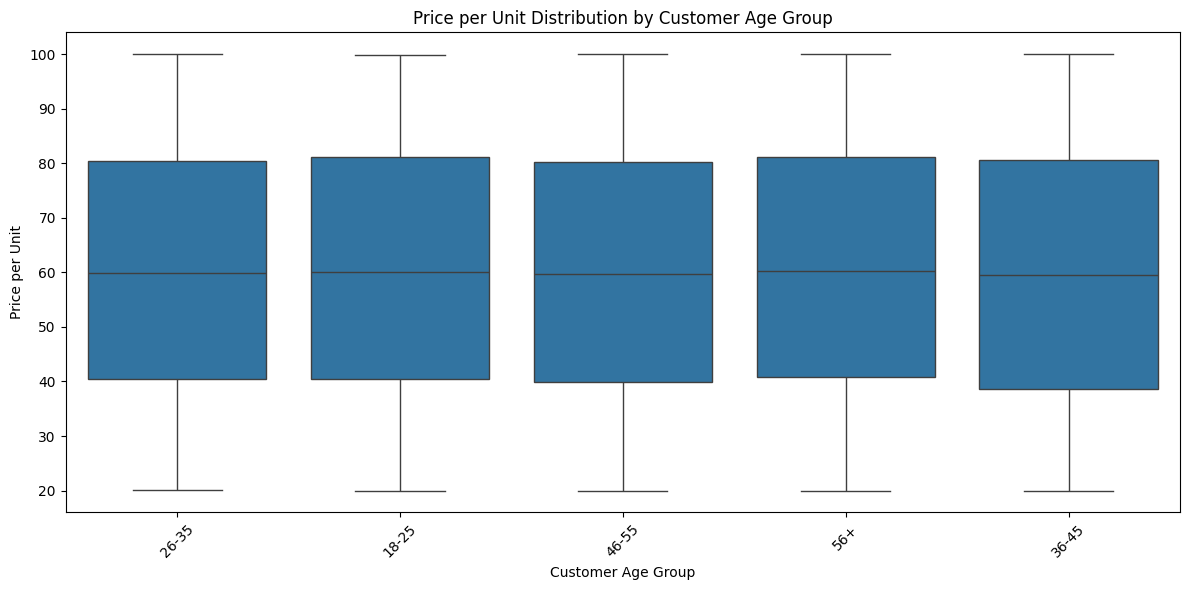

In [499]:


plt.figure(figsize=(12, 6))

filtered_df = df.dropna(subset=['Customer Age Group'])

sns.boxplot(data=filtered_df, x='Customer Age Group', y='Price per Unit')

plt.title('Price per Unit Distribution by Customer Age Group')
plt.xlabel('Customer Age Group')
plt.ylabel('Price per Unit')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [500]:
df['Customer Age Group'] = df.groupby(['Region','Product Category'])['Customer Age Group'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)


In [501]:
missing_summary = df.isnull().sum()
print("Missing values summary:\n", missing_summary)

Missing values summary:
 Invoice Number        0
Date Time             0
Customer ID           0
Product ID            0
Quantity              0
Price per Unit        0
Return Status         0
Sales Channel         0
Total Sales           0
Customer Age Group    0
Region                0
Product Category      0
date                  0
dtype: int64


## Outlier Handling in numerical fetures

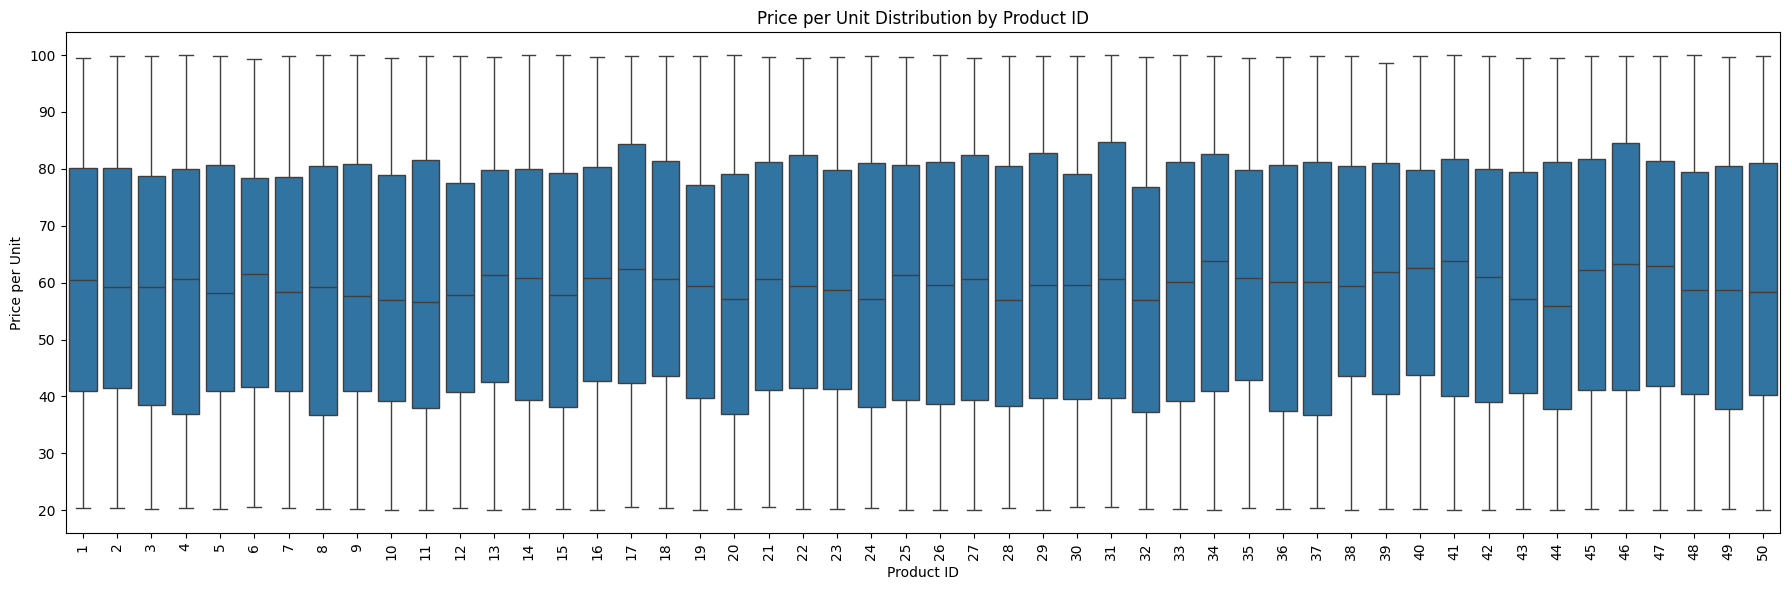

In [502]:
plt.figure(figsize=(18, 6))
sns.boxplot(x='Product ID', y='Price per Unit', data=df)
plt.xticks(rotation=90)
plt.title('Price per Unit Distribution by Product ID')
plt.tight_layout()
plt.show()


## Duplicates Handling

In [503]:
product_ids_with_duplicates = (
    df.groupby('Product ID')['Product Category']
    .nunique()
    .loc[lambda x: x > 1]
)

In [504]:
df_duplicates = (
    df[df['Product ID'].isin(product_ids_with_duplicates.index)]
    .groupby('Product ID')['Product Category']
    .unique()
    .reset_index()
    .rename(columns={'Product Category': 'Category List'})
)

In [505]:
print(df_duplicates.head())


   Product ID            Category List
0          19  [Footwear, Accessories]
1          29  [Footwear, Accessories]
2          42  [Footwear, Accessories]


In [506]:
df_cleaned = df[~df['Product ID'].isin(product_ids_with_duplicates.index)]


In [507]:
df_cleaned['year'] = pd.to_datetime(df_cleaned['date']).dt.year
df_cleaned.to_csv('preprocessed.csv', index=False)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_10852\134567883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['year'] = pd.to_datetime(df_cleaned['date']).dt.year


In [508]:
df_cleaned.to_csv('preprocessed.csv', index=False)


# KPI calculation

## Product Penetration

In [509]:
df=pd.read_csv("preprocessed.csv")

In [510]:
total_invoices = df['Invoice Number'].nunique()


In [511]:
product_invoice_counts = df.groupby('Product ID')['Invoice Number'].nunique()


In [512]:
product_penetration = (product_invoice_counts / total_invoices) * 100
product_penetration = product_penetration.reset_index().rename(columns={'Invoice Number': 'Penetration (%)'})

In [513]:
product_penetration.head()

,Product ID,Penetration (%)
0,1,2.040558
1,2,2.306717
2,3,2.306717
3,4,2.034221
4,5,2.338403


## Average Invoice Value

In [514]:
invoice_sales = df.groupby('Invoice Number')['Total Sales'].sum()


In [515]:
overall_aiv = invoice_sales.mean()


In [516]:
print(overall_aiv)

241.151618504436


In [517]:
segmented_age = df.groupby(['Invoice Number', 'Customer Age Group'])['Total Sales'].sum().reset_index()
aiv_by_age = segmented_age.groupby('Customer Age Group')['Total Sales'].mean().reset_index(name='AIV (by Age Group)')

In [518]:
segmented_channel = df.groupby(['Invoice Number', 'Sales Channel'])['Total Sales'].sum().reset_index()
aiv_by_channel = segmented_channel.groupby('Sales Channel')['Total Sales'].mean().reset_index(name='AIV (by Sales Channel)')

In [519]:
aiv_by_age.head()

,Customer Age Group,AIV (by Age Group)
0,18-25,241.880672
1,26-35,239.790726
2,36-45,242.442644
3,46-55,239.068250
4,56+,243.623001


In [520]:
aiv_by_channel.head()

,Sales Channel,AIV (by Sales Channel)
0,In-Store,241.527224
1,Online,240.905809


## Rate of Returned Products

In [521]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')


In [522]:
returned_qty = df[df['Return Status'] == 'Returned']['Quantity'].sum()
total_qty = df['Quantity'].sum()
return_rate_qty = (returned_qty / total_qty) * 100

In [523]:
returned_value = df[df['Return Status'] == 'Returned']['Total Sales'].sum()
total_value = df['Total Sales'].sum()
return_rate_value = (returned_value / total_value) * 100

In [524]:
print(return_rate_value)

1.1328709488191133


In [525]:
seg_qty = df.groupby(['Region', 'Return Status'])['Quantity'].sum().unstack(fill_value=0)
seg_qty['Return Rate (%)'] = (seg_qty.get('Returned', 0) / seg_qty.sum(axis=1)) * 100
a = seg_qty[['Return Rate (%)']].reset_index()

In [526]:
print(a.head())

Return Status Region  Return Rate (%)
0               East         1.146474
1              North         1.126626
2              South         0.745027
3               West         1.302488


In [527]:
seg_channel = df.groupby(['Sales Channel', 'Return Status'])['Quantity'].sum().unstack(fill_value=0)
seg_channel['Return Rate (%)'] = (seg_channel.get('Returned', 0) / seg_channel.sum(axis=1)) * 100
b = seg_channel[['Return Rate (%)']].reset_index()

In [528]:
print(b.head())

Return Status Sales Channel  Return Rate (%)
0                  In-Store         1.337846
1                    Online         0.944163


### Daily sales growth

In [529]:
import pandas as pd


daily_region_sales = df.groupby(['date', 'Region'])['Total Sales'].sum().reset_index()

daily_total_sales = (
    daily_region_sales
    .groupby('date')['Total Sales']
    .sum()
    .rename("Total Sales All Regions")
)

daily_region_sales = daily_region_sales.merge(daily_total_sales, on='date')

daily_region_sales['Region Daily Share %'] = (
    daily_region_sales['Total Sales'] / daily_region_sales['Total Sales All Regions']
) * 100

daily_region_sales['Sales Growth %'] = (
    daily_region_sales
    .groupby('Region')['Total Sales']
    .transform(lambda x: x.pct_change() * 100)
)

print(daily_region_sales.head())


         date Region  Total Sales  Total Sales All Regions  \
0  2021-01-01   East    107051.87                331626.12   
1  2021-01-01  North     67033.76                331626.12   
2  2021-01-01  South     74378.55                331626.12   
3  2021-01-01   West     83161.94                331626.12   
4  2021-01-02   East    119328.39                340445.76   

   Region Daily Share %  Sales Growth %  
0             32.280892             NaN  
1             20.213655             NaN  
2             22.428435             NaN  
3             25.077017             NaN  
4             35.050632       11.467824  
